In [8]:
!pip install ultralytics --quiet

In [9]:
import os
 
print("Contenido de /kaggle/input:")
print("─" * 50)
for item in os.listdir("/kaggle/input"):
    ruta = os.path.join("/kaggle/input", item)
    print(f"  📁 {item}")
 
    # Explorar un nivel más
    if os.path.isdir(ruta):
        for sub in os.listdir(ruta)[:10]:
            print(f"      └── {sub}")

Contenido de /kaggle/input:
──────────────────────────────────────────────────
  📁 notebooks
      └── mauriciotf
      └── amadeus1996
  📁 datasets
      └── moltean


In [12]:
import os

print("Contenido de /kaggle/input:")
print("─" * 50)
for item in os.listdir("/kaggle/input"):
    ruta = os.path.join("/kaggle/input", item)
    print(f"  📁 {item}")

    if os.path.isdir(ruta):
        for sub in os.listdir(ruta)[:10]:
            print(f"      └── {sub}")

Contenido de /kaggle/input:
──────────────────────────────────────────────────
  📁 notebooks
      └── mauriciotf
      └── amadeus1996
  📁 datasets
      └── moltean
      └── ggeoff


In [13]:
import os
 
base = "/kaggle/input/datasets/moltean"
 
print(f"Contenido de {base}:")
print("─" * 50)
for item in os.listdir(base):
    print(f"  📁 {item}")
    ruta = os.path.join(base, item)
    if os.path.isdir(ruta):
        for sub in os.listdir(ruta)[:15]:
            ruta2 = os.path.join(ruta, sub)
            tipo = "📁" if os.path.isdir(ruta2) else "📄"
            print(f"      {tipo} {sub}")
            # un nivel más si es carpeta
            if os.path.isdir(ruta2):
                for sub2 in os.listdir(ruta2)[:10]:
                    print(f"          └── {sub2}")

Contenido de /kaggle/input/datasets/moltean:
──────────────────────────────────────────────────
  📁 fruits
      📁 fruits-360_100x100
          └── fruits-360
      📁 fruits-360_3-body-problem
          └── fruits-360-3-body-problem
      📁 fruits-360_meta
          └── fruits-360-meta
      📁 fruits-360_original-size
          └── fruits-360-original-size
      📁 fruits-360_multi
          └── LICENSE
          └── README.md
          └── test-multiple_fruits


In [14]:
import os
 
train_dir = "/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training"
test_dir  = "/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Test"
 
todas_clases = sorted(os.listdir(train_dir))
print(f"Total de clases en Training: {len(todas_clases)}\n")
 
# Buscar las que coinciden con tus alimentos
PALABRAS_CLAVE = ["apple", "orange", "lemon", "carrot", "tomato", "pepper"]
 
print("CLASES QUE COINCIDEN CON TUS ALIMENTOS:")
print("═" * 50)
 
clases_relevantes = []
for clase in todas_clases:
    clase_lower = clase.lower()
    for palabra in PALABRAS_CLAVE:
        if palabra in clase_lower:
            n_imgs = len(os.listdir(os.path.join(train_dir, clase)))
            print(f"  {clase:30s} ({n_imgs} imágenes)")
            clases_relevantes.append(clase)
            break
 
print(f"\nTotal clases relevantes: {len(clases_relevantes)}")
 
# Comprobar también que existen en Test
print("\n" + "═" * 50)
print("Verificando que existen también en Test:")
for clase in clases_relevantes:
    existe = os.path.exists(os.path.join(test_dir, clase))
    print(f"  {clase:30s} {'✅' if existe else '❌'}")

Total de clases en Training: 260

CLASES QUE COINCIDEN CON TUS ALIMENTOS:
══════════════════════════════════════════════════
  Apple 10                       (699 imágenes)
  Apple 11                       (430 imágenes)
  Apple 12                       (466 imágenes)
  Apple 13                       (699 imágenes)
  Apple 14                       (466 imágenes)
  Apple 17                       (610 imágenes)
  Apple 18                       (724 imágenes)
  Apple 19                       (729 imágenes)
  Apple 20                       (702 imágenes)
  Apple 21                       (488 imágenes)
  Apple 22                       (696 imágenes)
  Apple 23                       (470 imágenes)
  Apple 5                        (440 imágenes)
  Apple 6                        (473 imágenes)
  Apple 7                        (694 imágenes)
  Apple 8                        (687 imágenes)
  Apple 9                        (694 imágenes)
  Apple Braeburn 1               (492 imágenes)
  Apple Cri

In [15]:
import os

train_dir = "/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training"
test_dir  = "/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Test"

todas_clases = sorted(os.listdir(train_dir))

# Prefijos que definen cada clase final en español
# Cualquier carpeta que EMPIECE por estos prefijos se agrupa en la clase
PREFIJOS = {
    "manzana":   ["Apple"],
    "limon":     ["Lemon"],
    "naranja":   ["Orange"],
    "zanahoria": ["Carrot"],
    "tomate":    ["Tomato"],
    "pimiento":  ["Pepper"],
}

MAPEO_CLASES = {}

for clase in todas_clases:
    for nombre_es, prefijos in PREFIJOS.items():
        for prefijo in prefijos:
            if clase.lower().startswith(prefijo.lower()):
                MAPEO_CLASES[clase] = nombre_es
                break

# Resumen
print("Mapeo generado automáticamente:\n")
resumen = {}
for origen, destino in MAPEO_CLASES.items():
    resumen.setdefault(destino, []).append(origen)

total_train_imgs = 0
for clase_es, carpetas in resumen.items():
    n_carpetas = len(carpetas)
    n_imgs = sum(len(os.listdir(os.path.join(train_dir, c))) for c in carpetas)
    total_train_imgs += n_imgs
    print(f"  {clase_es:12s} → {n_carpetas:2d} variedades, {n_imgs:5d} imágenes (train)")

print(f"\nTotal carpetas mapeadas: {len(MAPEO_CLASES)}")
print(f"Total imágenes de entrenamiento: {total_train_imgs}")

Mapeo generado automáticamente:

  manzana      → 30 variedades, 16571 imágenes (train)
  zanahoria    →  1 variedades,   151 imágenes (train)
  limon        →  2 variedades,   982 imágenes (train)
  naranja      →  5 variedades,  3325 imágenes (train)
  pimiento     → 11 variedades,  6242 imágenes (train)
  tomate       → 19 variedades, 10259 imágenes (train)

Total carpetas mapeadas: 68
Total imágenes de entrenamiento: 37530


**Construcción del dataset balanceado**

Se utilizan las rutas `fruits-360_100x100/fruits-360/Training` y `Test`. Cada clase se limita a un máximo de 300 imágenes de entrenamiento y 60 de validación, mezclando aleatoriamente las distintas variedades (`seed=42` para reproducibilidad). En el caso de la zanahoria, al disponer solo de 151 imágenes, se utilizan todas las existentes — el límite de 300 es un techo, no un mínimo. Esta limitación del dataset se documenta en el Capítulo 7.

In [16]:
import os
import shutil
import random

train_dir = "/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training"
test_dir  = "/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Test"

OUTPUT_DIR = "/kaggle/working/dataset_clasificacion"

# Límite máximo de imágenes por clase para balancear
# (zanahoria solo tiene 151, así que ese será el techo natural si
#  quieres clases perfectamente balanceadas; 300 es un buen compromiso
#  que documenta la limitación sin descartar demasiados datos)
MAX_IMAGENES_TRAIN = 300
MAX_IMAGENES_VAL   = 60

random.seed(42)

# Reconstruir el mapeo (igual que en Celda 3)
PREFIJOS = {
    "manzana":   ["Apple"],
    "limon":     ["Lemon"],
    "naranja":   ["Orange"],
    "zanahoria": ["Carrot"],
    "tomate":    ["Tomato"],
    "pimiento":  ["Pepper"],
}

todas_clases = sorted(os.listdir(train_dir))
MAPEO_CLASES = {}
for clase in todas_clases:
    for nombre_es, prefijos in PREFIJOS.items():
        for prefijo in prefijos:
            if clase.lower().startswith(prefijo.lower()):
                MAPEO_CLASES[clase] = nombre_es
                break

clases_finales = sorted(set(MAPEO_CLASES.values()))

# Crear estructura de carpetas
for split in ["train", "val"]:
    for clase_es in clases_finales:
        os.makedirs(os.path.join(OUTPUT_DIR, split, clase_es), exist_ok=True)

# Agrupar carpetas origen por clase destino
agrupado = {}
for origen, destino in MAPEO_CLASES.items():
    agrupado.setdefault(destino, []).append(origen)

# Copiar imágenes con límite y barajado
print("Construyendo dataset balanceado...\n")

for clase_es, carpetas_origen in agrupado.items():
    for split, dir_origen, max_imgs in [
        ("train", train_dir, MAX_IMAGENES_TRAIN),
        ("val",   test_dir,  MAX_IMAGENES_VAL),
    ]:
        # Recopilar todas las rutas de imagen de todas las variedades
        todas_rutas = []
        for carpeta in carpetas_origen:
            carpeta_path = os.path.join(dir_origen, carpeta)
            if not os.path.exists(carpeta_path):
                continue
            for img_file in os.listdir(carpeta_path):
                todas_rutas.append((carpeta, os.path.join(carpeta_path, img_file)))

        random.shuffle(todas_rutas)
        seleccionadas = todas_rutas[:max_imgs]

        carpeta_destino = os.path.join(OUTPUT_DIR, split, clase_es)
        for carpeta_origen, ruta_img in seleccionadas:
            nombre_archivo = os.path.basename(ruta_img)
            dst = os.path.join(
                carpeta_destino,
                f"{carpeta_origen.replace(' ', '_')}_{nombre_archivo}"
            )
            shutil.copy2(ruta_img, dst)

        print(f"  {clase_es:12s} [{split}]: {len(seleccionadas)} imágenes "
              f"(de {len(todas_rutas)} disponibles, {len(carpetas_origen)} variedades)")

print("\n✅ Dataset construido en:", OUTPUT_DIR)
print(f"\n⚠️  Nota para el TFM: la clase 'zanahoria' solo tiene 1 variedad")
print(f"   en Fruits-360 (151 imágenes train / ~26 test), frente a las")
print(f"   {MAX_IMAGENES_TRAIN} imágenes de las demás clases. Esto debe")
print(f"   documentarse como limitación del dataset en el Capítulo 7.")

Construyendo dataset balanceado...

  manzana      [train]: 300 imágenes (de 16571 disponibles, 30 variedades)
  manzana      [val]: 60 imágenes (de 5506 disponibles, 30 variedades)
  zanahoria    [train]: 151 imágenes (de 151 disponibles, 1 variedades)
  zanahoria    [val]: 50 imágenes (de 50 disponibles, 1 variedades)
  limon        [train]: 300 imágenes (de 982 disponibles, 2 variedades)
  limon        [val]: 60 imágenes (de 330 disponibles, 2 variedades)
  naranja      [train]: 300 imágenes (de 3325 disponibles, 5 variedades)
  naranja      [val]: 60 imágenes (de 1102 disponibles, 5 variedades)
  pimiento     [train]: 300 imágenes (de 6242 disponibles, 11 variedades)
  pimiento     [val]: 60 imágenes (de 2074 disponibles, 11 variedades)
  tomate       [train]: 300 imágenes (de 10259 disponibles, 19 variedades)
  tomate       [val]: 60 imágenes (de 3413 disponibles, 19 variedades)

✅ Dataset construido en: /kaggle/working/dataset_clasificacion

⚠️  Nota para el TFM: la clase 'zanaho

In [17]:
# ══════════════════════════════════════════════════════════════════
# CELDA 5 — Entrenar YOLOv8 en modo clasificación
# ══════════════════════════════════════════════════════════════════

from ultralytics import YOLO

print("Iniciando entrenamiento YOLOv8m-cls...")
print("Esto puede tardar 10-25 minutos con GPU.\n")

modelo = YOLO("yolov8m-cls.pt")

resultados = modelo.train(
    data    = OUTPUT_DIR,
    epochs  = 30,
    imgsz   = 224,
    batch   = 64,
    name    = "tfm_clasificador",
    project = "/kaggle/working/runs",
    patience= 8,
    device  = 0,
)

print("\n✅ Entrenamiento completado.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Iniciando entrenamiento YOLOv8m-cls...
Esto puede tardar 10-25 minutos con GPU.

Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset_clasificacion, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=to

**Interpretación de la accuracy obtenida**

El valor de accuracy es elevado porque Fruits-360 contiene imágenes con fondo blanco uniforme y un único objeto centrado, un escenario favorable para el clasificador. Este resultado no es extrapolable directamente a fotografías reales de nevera (fondos desordenados, múltiples objetos, iluminación variable, oclusiones). La arquitectura de dos etapas (localización + clasificación) descrita en el pipeline busca precisamente compensar esta diferencia entre las condiciones de validación interna y las condiciones de uso real, evaluadas por separado en el notebook 07.

In [18]:
# ══════════════════════════════════════════════════════════════════
# CELDA 6 — Evaluar el clasificador
# ══════════════════════════════════════════════════════════════════

import glob

best_model_path = glob.glob(
    "/kaggle/working/runs/tfm_clasificador*/weights/best.pt"
)[0]
print(f"Mejor modelo: {best_model_path}")

modelo_final = YOLO(best_model_path)
metricas = modelo_final.val(data=OUTPUT_DIR)

print("\n" + "═" * 60)
print("  MÉTRICAS DEL CLASIFICADOR — PARA EL CAPÍTULO 5")
print("═" * 60)
print(f"  Top-1 Accuracy: {metricas.top1:.3f}")
print(f"  Top-5 Accuracy: {metricas.top5:.3f}")
print("═" * 60)

Mejor modelo: /kaggle/working/runs/tfm_clasificador/weights/best.pt
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,770,342 parameters, 0 gradients, 41.6 GFLOPs
train: /kaggle/working/dataset_clasificacion/train... found 1651 images in 6 classes ✅ 
val: /kaggle/working/dataset_clasificacion/val... found 350 images in 6 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 190.8±55.6 MB/s, size: 4.3 KB)
val: Scanning /kaggle/working/dataset_clasificacion/val... 350 images, 0 corrupt: 100% ━━━━━━━━━━━━ 350/350 146.8Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 22/22 20.2it/s 1.1s0.1s
                   all      0.997          1
Speed: 0.2ms preprocess, 2.8ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val

════════════════════════════════════════════════════════════
  MÉTRICAS DEL CLASIFICADOR — PARA EL CAPÍT

In [19]:
# ══════════════════════════════════════════════════════════════════
# CELDA 7 — PIPELINE COMPLETO: Localización + Clasificación
# ══════════════════════════════════════════════════════════════════

import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Modelo 1: YOLOv8 preentrenado (COCO) para LOCALIZAR objetos
modelo_localizador = YOLO("yolov8m.pt")

# Modelo 2: tu clasificador entrenado para IDENTIFICAR el alimento
modelo_clasificador = YOLO(best_model_path)

CONFIANZA_LOCALIZACION = 0.25

def detectar_ingredientes(ruta_imagen):
    imagen = cv2.imread(ruta_imagen)
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

    resultados_loc = modelo_localizador(
        ruta_imagen, conf=CONFIANZA_LOCALIZACION, verbose=False
    )

    detecciones_finales = []

    for r in resultados_loc:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            recorte = imagen_rgb[y1:y2, x1:x2]

            if recorte.size == 0:
                continue

            resultado_cls = modelo_clasificador(recorte, verbose=False)
            top1_idx = resultado_cls[0].probs.top1
            top1_conf = float(resultado_cls[0].probs.top1conf)
            nombre_clase = modelo_clasificador.names[top1_idx]

            detecciones_finales.append({
                "ingrediente": nombre_clase,
                "confianza": round(top1_conf, 3),
                "bbox": (x1, y1, x2, y2)
            })

    return imagen_rgb, detecciones_finales


def mostrar_resultado(ruta_imagen):
    imagen_rgb, detecciones = detectar_ingredientes(ruta_imagen)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(imagen_rgb)

    for det in detecciones:
        x1, y1, x2, y2 = det["bbox"]
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              fill=False, edgecolor="lime", linewidth=2)
        ax.add_patch(rect)
        ax.text(x1, y1 - 5,
                f"{det['ingrediente']} ({det['confianza']:.0%})",
                color="white", fontsize=10, fontweight="bold",
                bbox=dict(facecolor="green", alpha=0.7))

    ax.axis("off")
    plt.title(f"Detección: {Path(ruta_imagen).name}")
    plt.tight_layout()
    plt.show()

    print("\nIngredientes detectados:")
    for det in detecciones:
        print(f"  • {det['ingrediente']}: {det['confianza']:.0%}")

print("✅ Pipeline de dos etapas listo.")

✅ Pipeline de dos etapas listo.


In [20]:
import os
multi_dir = "/kaggle/input/datasets/moltean/fruits/fruits-360_multi/test-multiple_fruits"
print(os.listdir(multi_dir)[:10])

['raspberry_27.jpg', 'eggplant_tomato_2.jpg', 'cherry_49.jpg', 'raspberry_16.jpg', 'apricot_4.jpg', 'pepper.jpg', 'mango_2.jpg', 'raspberry_22.jpg', 'pepper_2.jpg', 'peach_17.jpg']


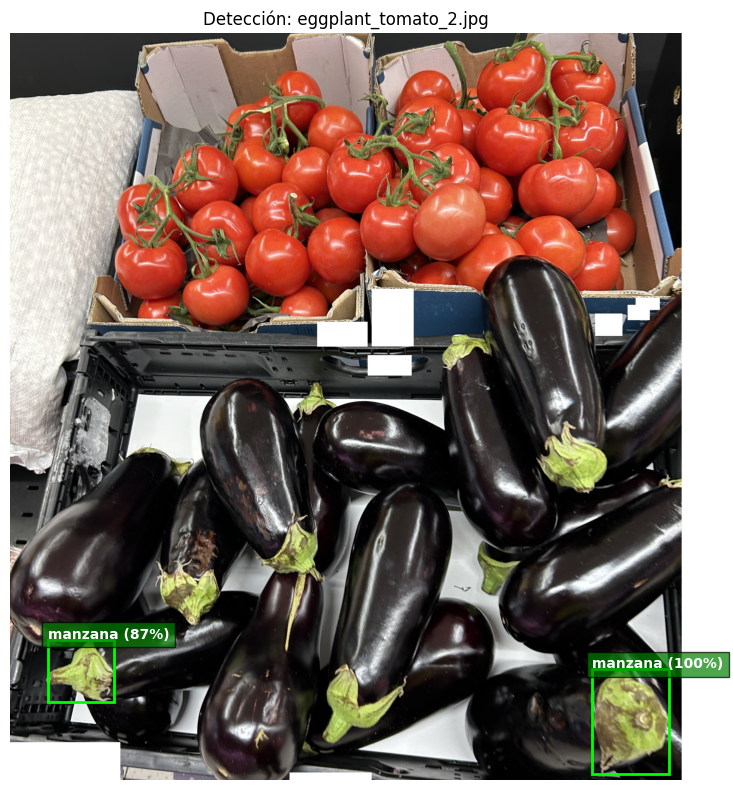


Ingredientes detectados:
  • manzana: 87%
  • manzana: 100%


In [21]:
import os

multi_dir = "/kaggle/input/datasets/moltean/fruits/fruits-360_multi/test-multiple_fruits"
mostrar_resultado(os.path.join(multi_dir, "eggplant_tomato_2.jpg"))